<a href="https://colab.research.google.com/github/vinayak932/Criminals-killings-in-USA-data-analysis/blob/main/Fatal_Force_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty.

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [ ]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 61.7 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


## Import Statements

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [ ]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [ ]:
df_fatalities.columns

Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='object')

In [ ]:
df_hh_income.isna().sum()
df_hh_income = df_hh_income.dropna()

In [ ]:
df_fatalities.isna().sum()
df_fatalities = df_fatalities.dropna()

## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate.

In [ ]:
df_share_race_city.duplicated().sum()

np.int64(0)

In [ ]:
df_fatalities.duplicated().sum()

np.int64(0)

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [ ]:
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')
state_povert = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().reset_index()
state_povert.head()

,Geographic Area,poverty_rate
0,AK,19.85
1,AL,20.65
2,AR,22.96
3,AZ,25.67
4,CA,17.12


In [ ]:
fig = px.bar(state_povert, x='Geographic Area', y='poverty_rate', title='Povert Rate In Each US State')
fig.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [ ]:
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce')
state_completed_hs = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().reset_index()

In [ ]:
fig = px.bar(state_completed_hs, x='Geographic Area', y='percent_completed_hs', title='High School Graduation Rate By US State')
fig.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [ ]:
poverty_rate_and_hs_rate = state_povert.merge(state_completed_hs, on="Geographic Area", how="left")
poverty_rate_and_hs_rate.head()

,Geographic Area,poverty_rate,percent_completed_hs
0,AK,19.85,84.63
1,AL,20.65,80.30
2,AR,22.96,79.95
3,AZ,25.67,80.47
4,CA,17.12,81.96


In [ ]:
fig = px.line(poverty_rate_and_hs_rate, x='Geographic Area', y=['poverty_rate', 'percent_completed_hs'], title='Comparison chart of povert rate and highschool completion rate')
fig.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

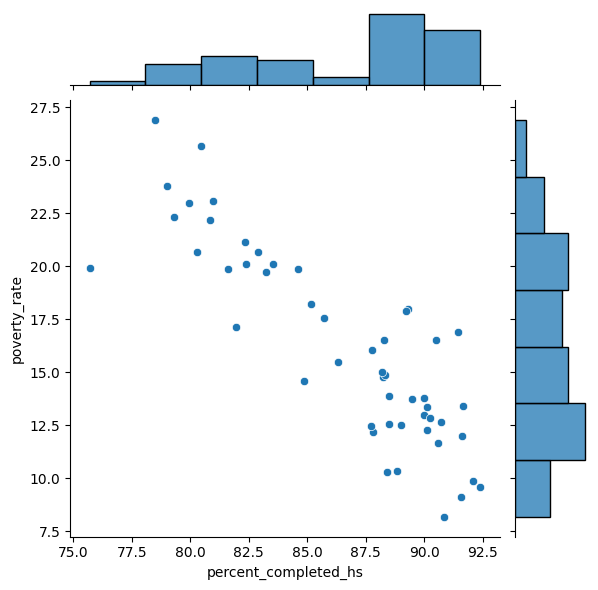

In [ ]:
sns.jointplot(data=poverty_rate_and_hs_rate, x='percent_completed_hs', y='poverty_rate')

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio.

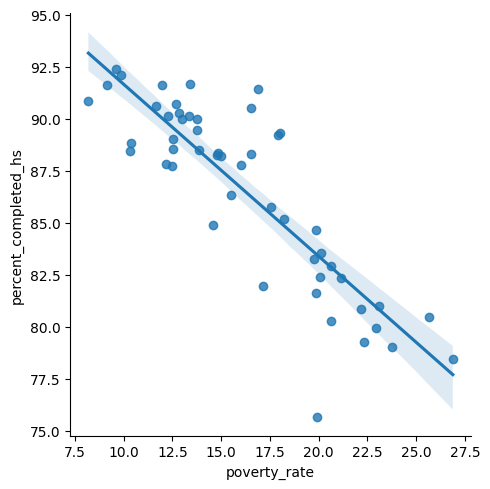

In [ ]:
sns.lmplot(data=poverty_rate_and_hs_rate, y='percent_completed_hs', x='poverty_rate')

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections.

In [ ]:
df_share_race_city['share_asian'] = pd.to_numeric(df_share_race_city['share_asian'],errors='coerce')
df_share_race_city['share_black'] = pd.to_numeric(df_share_race_city['share_black'],errors='coerce')
df_share_race_city['share_white'] = pd.to_numeric(df_share_race_city['share_white'], errors='coerce')
df_share_race_city['share_native_american'] = pd.to_numeric(df_share_race_city['share_native_american'], errors='coerce')
df_share_race_city['share_hispanic'] = pd.to_numeric(df_share_race_city['share_hispanic'], errors='coerce')
state_race = df_share_race_city.groupby('Geographic area')[['share_white','share_black','share_native_american','share_asian','share_hispanic']].mean().reset_index()

In [ ]:
fig = px.bar(state_race, x='Geographic area', y=['share_white','share_black','share_native_american','share_asian','share_hispanic'], title='Racial Makeup Of Each US State')
fig.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [ ]:
death_count_byrace = df_fatalities.groupby('race').value_counts().reset_index()
death_count_byrace.head()

,race,id,name,date,manner_of_death,armed,age,gender,city,state,signs_of_mental_illness,threat_level,flee,body_camera,count
0,A,3,Tim Elliot,02/01/15,shot,gun,53.00,M,Shelton,WA,True,attack,Not fleeing,False,1
1,A,195,Hung Trieu,01/03/15,shot,gun,35.00,M,Houston,TX,False,attack,Not fleeing,False,1
2,A,249,Carl Lao,04/03/15,shot,gun,28.00,M,Stockton,CA,False,attack,Not fleeing,False,1
3,A,346,Matautu Nuu,28/01/15,shot and Tasered,hammer,35.00,M,Stockton,CA,True,attack,Not fleeing,False,1
4,A,359,Joseph Jeremy Weber,08/04/15,shot,knife,28.00,M,Sunnyvale,CA,True,other,Not fleeing,False,1


In [ ]:
fig = px.pie(death_count_byrace, values='count', names='race', title='People Killed By Race')
fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women.

In [ ]:
death_count_bygender = df_fatalities.groupby('gender').value_counts().reset_index()
death_count_bygender.head()

,gender,id,name,date,manner_of_death,armed,age,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,count
0,F,16,Autumn Steele,06/01/15,shot,unarmed,34.00,W,Burlington,IA,False,other,Not fleeing,True,1
1,F,20,Jessie Hernandez,26/01/15,shot,vehicle,17.00,H,Denver,CO,False,other,Not fleeing,False,1
2,F,100,Kristiana Coignard,22/01/15,shot and Tasered,knife,17.00,W,Longview,TX,True,other,Not fleeing,False,1
3,F,111,Tiffany Terry,27/01/15,shot,knife,39.00,W,Omaha,NE,True,attack,Not fleeing,False,1
4,F,118,Yuvette Henderson,03/02/15,shot,gun,38.00,B,Emeryville,CA,False,attack,Car,False,1


In [ ]:
fig = px.pie(death_count_bygender, values='count', names='gender', title='Total Number Of Deaths Of Mens And Women')
fig.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death?

In [ ]:
manner_of_death = df_fatalities.groupby('manner_of_death')['gender'].size().reset_index()
manner_of_death.head()

,manner_of_death,gender
0,shot,2100
1,shot and Tasered,154


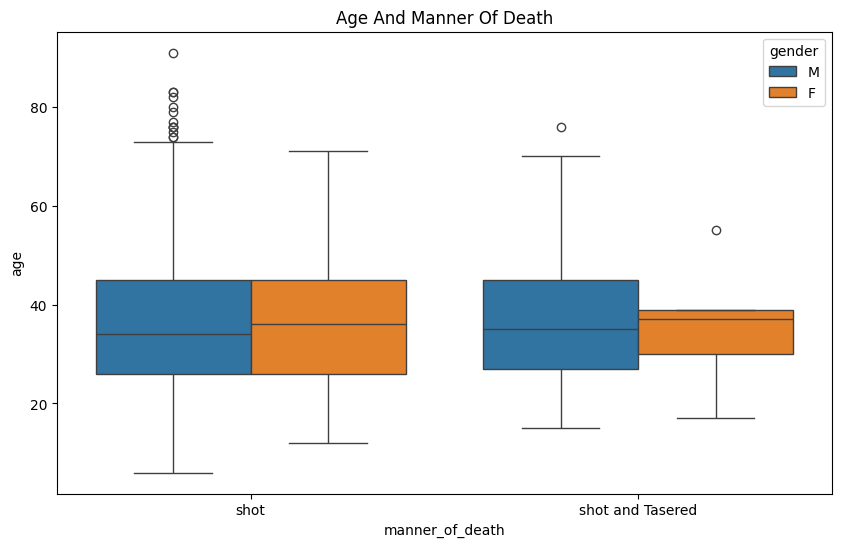

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_fatalities,
    y='age',
    x='manner_of_death',
    hue='gender'
)
plt.title('Age And Manner Of Death')
plt.show()

# Were People Armed?

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed?

In [ ]:
armed_people = df_fatalities['armed'].value_counts().reset_index()
armed_people.head()


,armed,count
0,gun,1247
1,knife,324
2,unarmed,165
3,vehicle,158
4,toy weapon,102


In [ ]:
top_weapons = armed_people.head(5)
others = armed_people.iloc[5:].sum()
weapon_plot = pd.concat([
    top_weapons,
    pd.Series({'others' : others})
])
weapon_plot = weapon_plot.drop(columns=[0])
weapon_plot.head()


,armed,count
0,gun,"1,247.00"
1,knife,324.00
2,unarmed,165.00
3,vehicle,158.00
4,toy weapon,102.00


In [ ]:
fig = px.pie( values=weapon_plot['count'], names=weapon_plot['armed'], title='People were armed with which weapon')
fig.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [ ]:
df_fatalities['age'] = pd.to_numeric(df_fatalities['age'], errors = 'coerce')
under_25 = df_fatalities[df_fatalities['age'] <= 25]
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [ ]:
under_25_count = under_25.value_counts().sum()
total_fatalities = df_fatalities.value_counts().sum()
pct_of_people_under25 = under_25_count / total_fatalities * 100
print(pct_of_people_under25)

22.937000887311445


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police.

In [ ]:
people_by_age = df_fatalities.groupby('age').value_counts().reset_index()
fig = px.histogram(people_by_age, x='age', title='Distribution Of Ages Of The People Killed By Police')
fig.show()

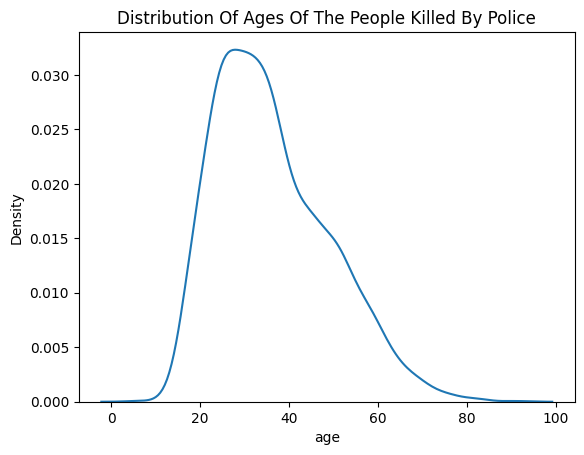

In [ ]:
sns.kdeplot(people_by_age, x='age')
plt.title('Distribution Of Ages Of The People Killed By Police')
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions?

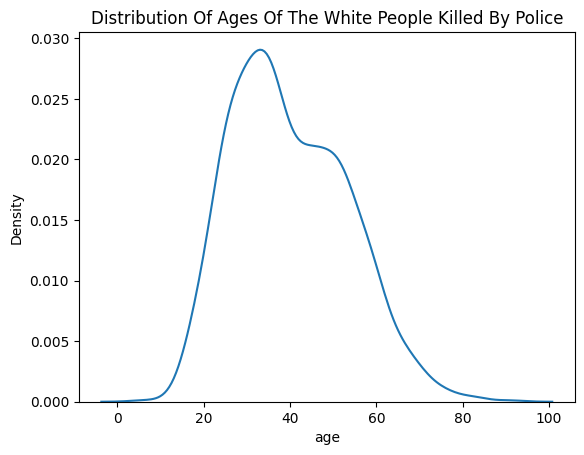

In [ ]:
white_americans = df_fatalities.loc[df_fatalities['race'] == 'W'].value_counts().reset_index()
sns.kdeplot(white_americans, x='age')
plt.title('Distribution Of Ages Of The White People Killed By Police')
plt.show()

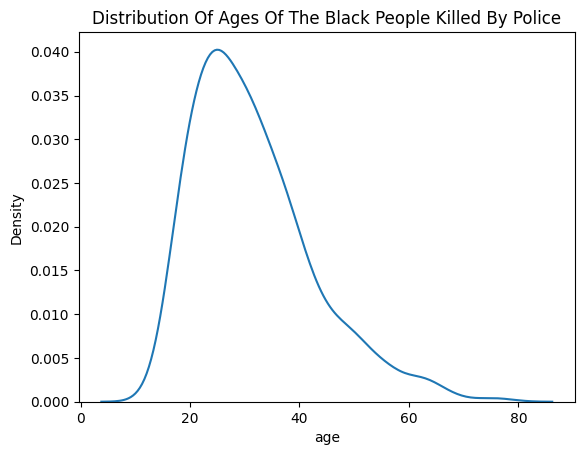

In [ ]:
black_americans = df_fatalities.loc[df_fatalities['race'] == 'B'].value_counts().reset_index()
sns.kdeplot(black_americans, x='age')
plt.title('Distribution Of Ages Of The Black People Killed By Police')
plt.show()

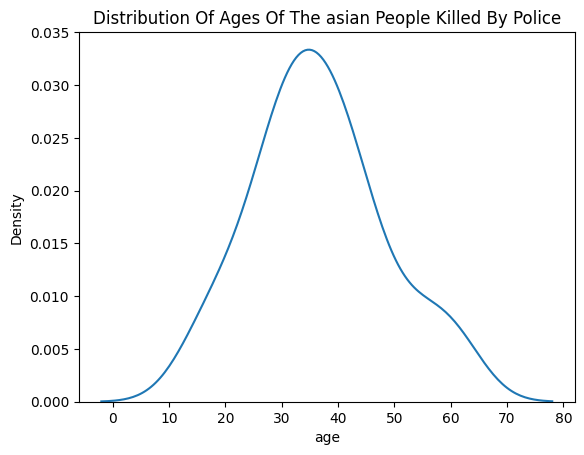

In [ ]:
asians = df_fatalities.loc[df_fatalities['race'] == 'A'].value_counts().reset_index()
sns.kdeplot(asians, x='age')
plt.title('Distribution Of Ages Of The asian People Killed By Police')
plt.show()

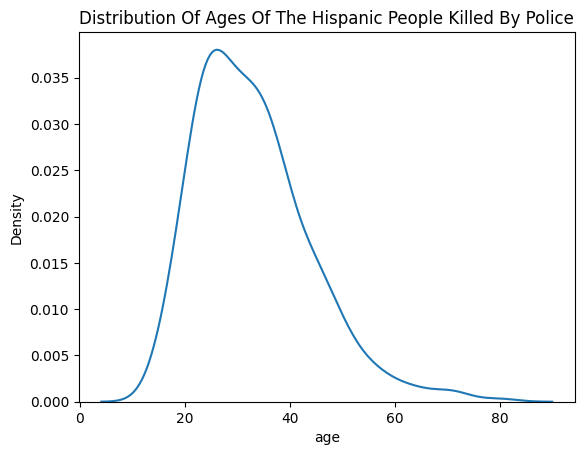

In [ ]:
Hispanic = df_fatalities.loc[df_fatalities['race'] == 'H'].value_counts().reset_index()
sns.kdeplot(Hispanic, x='age')
plt.title('Distribution Of Ages Of The Hispanic People Killed By Police')
plt.show()

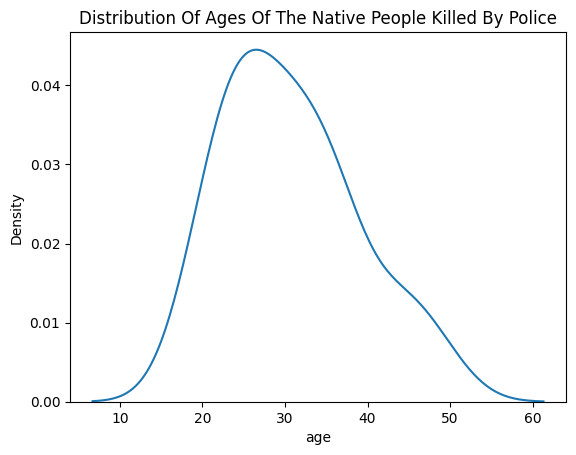

In [ ]:
native_americans = df_fatalities.loc[df_fatalities['race'] == 'N'].value_counts().reset_index()
sns.kdeplot(native_americans, x='age')
plt.title('Distribution Of Ages Of The Native People Killed By Police')
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race.

In [ ]:
total_killings_byrace = df_fatalities.groupby('race').value_counts().reset_index()
total_killings_byrace.head()

,race,id,name,date,manner_of_death,armed,age,gender,city,state,signs_of_mental_illness,threat_level,flee,body_camera,count
0,A,3,Tim Elliot,02/01/15,shot,gun,53.00,M,Shelton,WA,True,attack,Not fleeing,False,1
1,A,195,Hung Trieu,01/03/15,shot,gun,35.00,M,Houston,TX,False,attack,Not fleeing,False,1
2,A,249,Carl Lao,04/03/15,shot,gun,28.00,M,Stockton,CA,False,attack,Not fleeing,False,1
3,A,346,Matautu Nuu,28/01/15,shot and Tasered,hammer,35.00,M,Stockton,CA,True,attack,Not fleeing,False,1
4,A,359,Joseph Jeremy Weber,08/04/15,shot,knife,28.00,M,Sunnyvale,CA,True,other,Not fleeing,False,1


In [ ]:
fig = px.pie(total_killings_byrace, names='race', values='count')
fig.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [ ]:
sign_of_mentalillness = df_fatalities.loc[df_fatalities['signs_of_mental_illness'] == True].value_counts().sum()
print(sign_of_mentalillness)

573


In [ ]:
pct_of_mentalpatient = sign_of_mentalillness/total_fatalities * 100
print(pct_of_mentalpatient)

25.42147293700089


# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [ ]:
top_10_cities = (df_fatalities[['city','race']].value_counts().head(10).reset_index(name='value'))
print(top_10_cities)

          city race  value
0      Chicago    B     19
1  Los Angeles    H     18
2      Houston    B     14
3       Austin    W     13
4      Phoenix    W     12
5    St. Louis    B     11
6      Phoenix    H     11
7  San Antonio    H     11
8  Los Angeles    B     10
9   Washington    B     10


In [ ]:
fig = px.pie(top_10_cities, names='city', values='value', title='Top 10 cities With The Most Police Killings')
fig.show()